In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import func


In [2]:
def v_sample(vlaw):
    if vlaw == 'beta_04':
        v = func.v_generate(k, beta=0.4)
    if vlaw == 'beta_07':
        v = func.v_generate(k, beta=0.7)
    if vlaw == 'dense':
        v = np.linspace(2.5, 1, k)
        v /= np.linalg.norm(v)
    if vlaw == 'exp':
        v = np.array([np.exp(-i/20) for i in range(k)])
        v /= np.linalg.norm(v)
    return v

In [ ]:
Delta = 0.04
k = 100
d = 200

sig = lambda x: tf.nn.tanh(2*x) - 0.729477*x
sig_np = lambda x: np.tanh(2*x) - 0.729477*x


g, dg, l_e, m_e, l_s, m_s = func.sig_related(sig_np)

In [4]:
# vlaws = ['beta_04', 'beta_07', 'dense', 'exp']
vlaws = ['beta_04']
alphas = np.linspace(0, 3, 201)

errs = []
for vlaw in vlaws:
    v = v_sample(vlaw)
    err = [func.solve(int(alpha*d**2), d, Delta, v, g, m_e)[0] for alpha in alphas]
    errs.append(err)
    

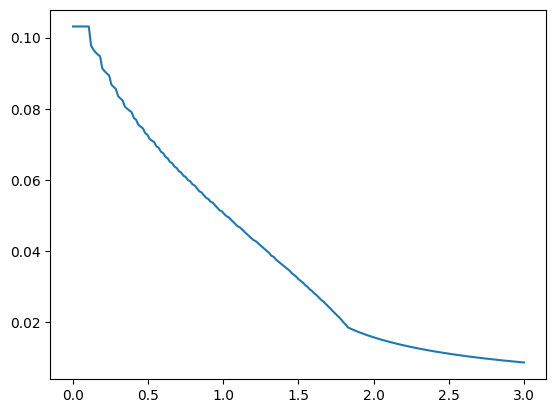

In [ ]:
errs_a = np.array(errs)
for err in errs_a:
    plt.plot(alphas, err)
plt.show()